In [1]:
# Tamaño de imagen configurable (alto, ancho).
IMAGE_SIZE = (224, 224)

# Nombres y rutas configurables para guardar y cargar los modelos.
MODEL_NAME = "models/cat_dog_mobilenetv3DataAugmentationZoomOutV4"
MODEL_PATH = f"{MODEL_NAME}.keras"
WEIGHTS_PATH = f"{MODEL_NAME}.weights.h5"
TFLITE_PATH = f"{MODEL_NAME}.tflite"
OPTIMIZED_TFLITE_PATH = f"{MODEL_NAME}_optimized.tflite"
CHECKPOINT_DIR = "checkpoints"
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/stage4.keras"


In [2]:
#clone from https://huggingface.co/Kavindutharaka/cat_dog_classifier/blob/main/cat_dog_classifier.ipynb

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
import opendatasets as od
import cv2

I0000 00:00:1789583096.177017   77914 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789583097.269097   77914 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
#od.download("https://www.kaggle.com/datasets/dineshpiyasamara/cats-and-dogs-for-classification")

In [5]:
BATCH_SIZE = 32


In [6]:
train_data_dir = "content/cats-and-dogs-for-classification/cats_dogs/train_crop075"
test_data_dir = "content/cats-and-dogs-for-classification/cats_dogs/test"

In [7]:
#from pathlib import Path
#from PIL import Image

#imagenes = []
#extensiones = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp", ".tif", ".tiff"}

#for ruta in Path(train_data_dir).rglob("*"):
#    if ruta.is_file() and ruta.suffix.lower() in extensiones:
#        with Image.open(ruta) as imagen:
#            ancho, alto = imagen.size
#        imagenes.append((ancho, alto, ruta))

#if not imagenes:
#    raise ValueError(f"No se encontraron imágenes en {train_data_dir}")

#print(f"Imágenes analizadas: {len(imagenes)}")
#print(f"Ancho mínimo: {min(x[0] for x in imagenes)} px")
#print(f"Ancho máximo: {max(x[0] for x in imagenes)} px")
#print(f"Alto mínimo:  {min(x[1] for x in imagenes)} px")
#print(f"Alto máximo:  {max(x[1] for x in imagenes)} px")

# Imágenes con menor y mayor número total de píxeles.
#menor = min(imagenes, key=lambda x: x[0] * x[1])
#mayor = max(imagenes, key=lambda x: x[0] * x[1])

#for etiqueta, (ancho, alto, ruta) in [("Menor", menor), ("Mayor", mayor)]:
#    print(f"\n{etiqueta}: {ancho} × {alto} px (ancho × alto)")
#    print(f"Archivo: {ruta}")
    

In [8]:
#from ultralytics import YOLO                                                                                                                     
#from pathlib import Path
#import numpy as np

#model = YOLO("yolov8n.pt")                                                                                                                       
#ratios, missing = [], 0                                                                                                                          
#for path in Path("content/cats-and-dogs-for-classification/cats_dogs/train").rglob("*.jpg"):                                                                                                                                    
#  result = model(path, classes=[15, 16], verbose=False)[0]                                                                                     
#  if len(result.boxes) == 0:                                                                                                                   
#      missing += 1                                                                                                                             
#      continue                                                                                                                                 
#  x1, y1, x2, y2 = result.boxes.xyxy[result.boxes.conf.argmax()].tolist()                                                                      
#  h, w = result.orig_shape                                                                                                                     
#  ratios.append((x2 - x1) * (y2 - y1) / (w * h))                                                                                               
                                                                                                                                               
#ratios = np.array(ratios)                                                                                                                        
#print("no animal detected:", missing)                                                                                                            
#print("box area fraction percentiles 5/25/50/75/95:", np.percentile(ratios, [5,25, 50, 75, 95]).round(2))



In [9]:
train_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset='training',
                                                         validation_split=0.1,
                                                         seed=42)
validation_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                         batch_size=BATCH_SIZE,
                                                         image_size=IMAGE_SIZE,
                                                         subset='validation',
                                                         validation_split=0.1,
                                                         seed=42)
test_data = tf.keras.utils.image_dataset_from_directory(test_data_dir,
                                                        batch_size=BATCH_SIZE,
                                                        image_size=IMAGE_SIZE)

Found 7050 files belonging to 2 classes.
Using 6345 files for training.


W0000 00:00:1789583097.907025   77914 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789583097.909975   77914 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789583097.980685   77914 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.


Found 7050 files belonging to 2 classes.
Using 705 files for validation.
Found 2000 files belonging to 2 classes.


In [10]:
class_names = train_data.class_names
class_names

['cats', 'dogs']

In [11]:
for image_batch, label_batch in train_data.take(1):
  print(image_batch.shape)
  print(label_batch.shape)

(32, 224, 224, 3)
(32,)


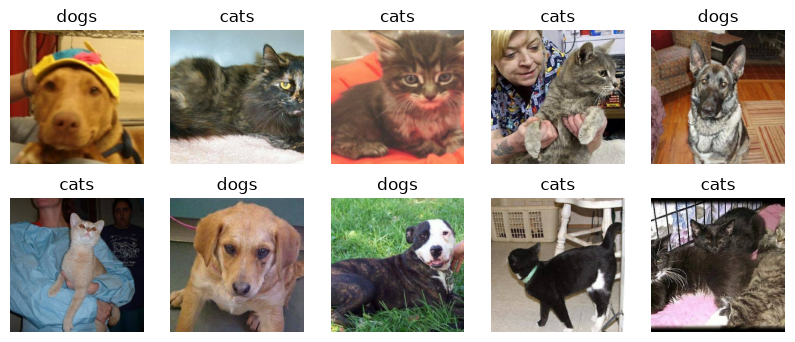

In [12]:
plt.figure(figsize=(10,4))
for image,label in train_data.take(1):
  for i in range(10):
    ax = plt.subplot(2,5,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(class_names[label[i]])
    plt.axis('off')

In [13]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal",input_shape=(*IMAGE_SIZE, 3)),
        #tf.keras.layers.RandomRotation(0.2),
        #tf.keras.layers.RandomZoom(0.2),
        #tf.keras.layers.RandomZoom(
        #    height_factor=(-0.2, 0.2),
        #    width_factor=(-0.2, 0.2)
        #),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.15, 0.50),
            fill_mode="constant",
            fill_value=255.0
        )
    ]
)

/opt/conda/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


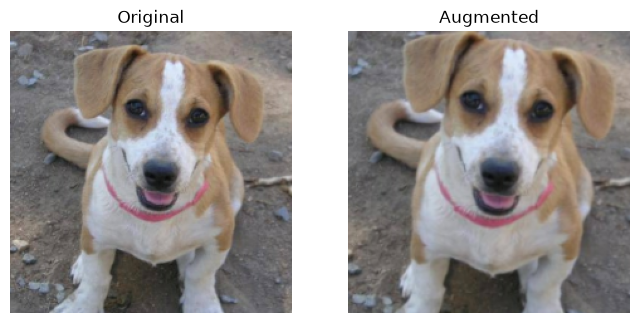

In [14]:
images, labels = next(iter(train_data))

image = images[0]

augmented_image = data_augmentation(
    tf.expand_dims(image, axis=0),
    training=True
)[0]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(tf.cast(image, tf.uint8))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(tf.cast(augmented_image, tf.uint8))
plt.title("Augmented")
plt.axis("off")

plt.show()

In [15]:
for image,label in train_data.take(1):
  for i in range(1):
    print(image)

tf.Tensor(
[[[[105.50077  158.50078   78.50077 ]
   [135.48012  188.48012  109.61851 ]
   [126.03328  179.21327  101.57325 ]
   ...
   [127.33595  175.33595  123.5218  ]
   [146.17422  194.17422  145.95824 ]
   [151.14249  198.33221  151.95276 ]]

  [[114.91685  168.48605   89.624435]
   [124.32046  177.88965  100.166435]
   [117.93851  171.9164    95.872154]
   ...
   [120.51274  168.51274  116.6154  ]
   [133.88327  181.88327  132.74484 ]
   [149.73448  196.92421  150.54475 ]]

  [[117.49635  171.49635   95.39368 ]
   [108.68811  162.68811   86.643875]
   [105.67532  159.67531   84.57527 ]
   ...
   [121.48957  169.48956  117.59223 ]
   [136.12483  184.12483  134.16907 ]
   [152.17741  199.36714  152.62772 ]]

  ...

  [[234.82172  249.51569  159.82172 ]
   [227.69594  243.58676  154.40353 ]
   [213.51897  229.47028  141.51897 ]
   ...
   [ 98.25555  142.25555  107.204216]
   [109.97154  153.97154  118.92021 ]
   [ 99.02271  140.5919   106.39243 ]]

  [[212.548    229.19896  137.548 

In [16]:
#transfer learning
pretrained_model = tf.keras.applications.xception.Xception(include_top=False,
                                                           input_shape=(*IMAGE_SIZE, 3),
                                                           weights='imagenet',
                                                           pooling='max')
for layer in pretrained_model.layers:
  layer.trainable = False

In [17]:
MobileNetV3Small = tf.keras.applications.MobileNetV3Small(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
#for layer in MobileNetV3Small.layers[:-20]:
#    layer.trainable = False
    
MobileNetV3Small.trainable = False
MobileNetV3Small.summary()

Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

In [18]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        #tf.keras.layers.RandomRotation(0.2),
        #tf.keras.layers.RandomZoom(0.2),
         tf.keras.layers.RandomZoom(
            height_factor=(-0.15, 0.50),
            fill_mode="constant",
            fill_value=255.0
        )
    ]
)

In [19]:
callbacks = [
        tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        mode="min"
    )
]

In [20]:
inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = MobileNetV3Small(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

#modelV2 = tf.keras.Sequential([
#    tf.keras.Input(shape=(*IMAGE_SIZE, 3)),
    #data_augmentation,
#    MobileNetV3Small,
#    tf.keras.layers.GlobalAveragePooling2D(),
#    tf.keras.layers.Dropout(0.2),
#    tf.keras.layers.Dense(1, activation="sigmoid"),
#])

In [21]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [22]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']
             )

In [23]:
epochs = 100

In [24]:

start_time = time.time()

history_transfer  = model.fit(
    train_data,
    epochs=epochs,
    validation_data=validation_data,
    callbacks= callbacks
)
end_time = time.time()

Epoch 1/100


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1789583111.783670   78075 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


196/199 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9260 - loss: 0.2076

E0000 00:00:1789583121.553727   78076 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9266 - loss: 0.2062

E0000 00:00:1789583139.621872   78078 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.9266 - loss: 0.2062 - val_accuracy: 0.9801 - val_loss: 0.0768
Epoch 2/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9764 - loss: 0.0747 - val_accuracy: 0.9816 - val_loss: 0.0561
Epoch 3/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9789 - loss: 0.0626 - val_accuracy: 0.9830 - val_loss: 0.0504
Epoch 4/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9803 - loss: 0.0545 - val_accuracy: 0.9844 - val_loss: 0.0451
Epoch 5/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9817 - loss: 0.0516 - val_accuracy: 0.9830 - val_loss: 0.0430
Epoch 6/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9852 - loss: 0.0436 - val_accuracy: 0.9844 - val_loss: 0.0407
Epoch 7/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9841 - loss: 0.0448 - val_accuracy: 0.9844 - val_loss: 0.0396
Epoch 8/100
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9842 - loss: 0.0419 - val_accuracy: 0

In [25]:
history_transfer .history

{'accuracy': [0.9265563488006592,
  0.9763593673706055,
  0.9788810014724731,
  0.9802994728088379,
  0.9817178845405579,
  0.9851852059364319,
  0.9840819835662842,
  0.9842395782470703,
  0.9864460229873657,
  0.9851852059364319,
  0.9858155846595764,
  0.9855003952980042,
  0.985027551651001,
  0.9866036176681519,
  0.9872340559959412,
  0.9858155846595764,
  0.988494873046875,
  0.9881796836853027,
  0.9891253113746643,
  0.9864460229873657,
  0.9889677166938782,
  0.9878644347190857,
  0.9888100624084473,
  0.9888100624084473,
  0.988494873046875,
  0.988494873046875,
  0.9888100624084473,
  0.9875492453575134,
  0.9892829060554504,
  0.9886524677276611,
  0.9888100624084473,
  0.9881796836853027,
  0.9897556900978088,
  0.9894405007362366,
  0.9886524677276611,
  0.9907013177871704],
 'loss': [0.20615558326244354,
  0.07469654083251953,
  0.06262500584125519,
  0.054523780941963196,
  0.05162646993994713,
  0.04359940439462662,
  0.04481513425707817,
  0.04193383455276489,
  0.03

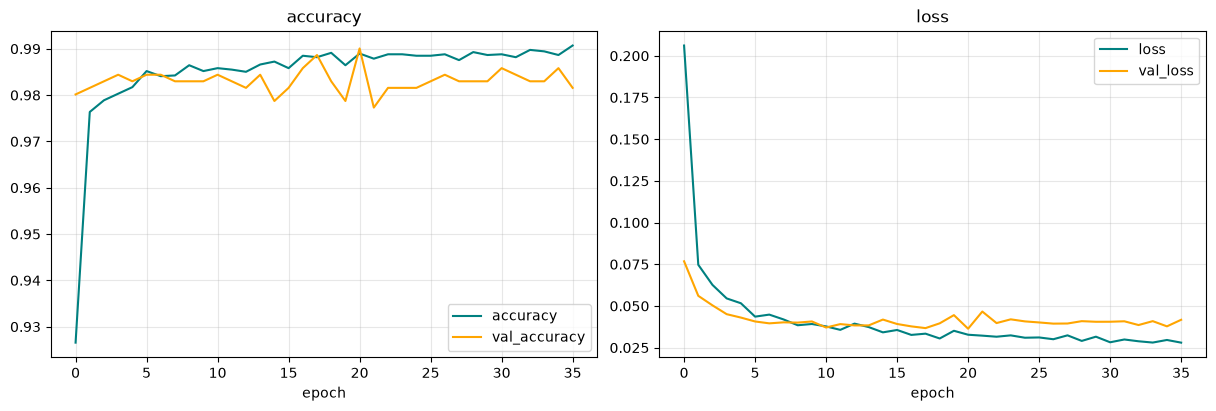

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)

axs[0].plot(history_transfer .history["accuracy"], color="teal", label="accuracy")
axs[0].plot(history_transfer .history["val_accuracy"], color="orange", label="val_accuracy")
axs[0].set_title("accuracy")

axs[1].plot(history_transfer .history["loss"], color="teal", label="loss")
axs[1].plot(history_transfer .history["val_loss"], color="orange", label="val_loss")
axs[1].set_title("loss")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

In [27]:
timeV = end_time - start_time
timeV = timeV/60
timeV

1.7731347799301147

In [28]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

In [29]:
for batch in test_data.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  precision.update_state(y, yhat)
  recall.update_state(y, yhat)
  accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━

E0000 00:00:1789583223.634987   78076 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


In [30]:
print(f"precision: {precision.result()}")
print(f"recall: {recall.result()}")
print(f"accuracy: {accuracy.result()}")

precision: 0.9770916104316711
recall: 0.9810000061988831
accuracy: 0.9789999723434448


In [31]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
model.save(CHECKPOINT_PATH)

In [32]:
#fine tunning
MobileNetV3Small.trainable = True

for layer in MobileNetV3Small.layers[:-20]:
    layer.trainable = False

for layer in MobileNetV3Small.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

fine_tune_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        mode="min"
    )
]

model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']
             )

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 940,853 (3.59 MB)

 Trainable params: 347,473 (1.33 MB)

 Non-trainable params: 592,224 (2.26 MB)

 Optimizer params: 1,156 (4.52 KB)

In [33]:

start_time = time.time()

history_finetune  = model.fit(
    train_data,
    epochs=50,
    validation_data=validation_data,
    callbacks=fine_tune_callbacks
)
end_time = time.time()

Epoch 1/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 23s 71ms/step - accuracy: 0.9888 - loss: 0.0312 - val_accuracy: 0.9901 - val_loss: 0.0356
Epoch 2/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9899 - loss: 0.0282 - val_accuracy: 0.9872 - val_loss: 0.0354
Epoch 3/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9899 - loss: 0.0275 - val_accuracy: 0.9872 - val_loss: 0.0351
Epoch 4/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9913 - loss: 0.0252 - val_accuracy: 0.9887 - val_loss: 0.0343
Epoch 5/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9905 - loss: 0.0253 - val_accuracy: 0.9858 - val_loss: 0.0354
Epoch 6/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9916 - loss: 0.0238 - val_accuracy: 0.9858 - val_loss: 0.0352
Epoch 7/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9924 - loss: 0.0226 - val_accuracy: 0.9858 - val_loss: 0.0345
Epoch 8/50
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9934 - loss: 0.0198 - val_accuracy

In [34]:
history_finetune .history

{'accuracy': [0.9888100624084473,
  0.9899133443832397,
  0.9899133443832397,
  0.9913317561149597,
  0.9905437231063843,
  0.991646945476532,
  0.9924349784851074,
  0.993380606174469,
  0.9936957955360413,
  0.9925925731658936,
  0.993380606174469,
  0.9932230114936829,
  0.9941686391830444,
  0.9947990775108337],
 'loss': [0.031208593398332596,
  0.028196364641189575,
  0.02750287391245365,
  0.02520478516817093,
  0.02528342790901661,
  0.02380869910120964,
  0.022585080936551094,
  0.019843626767396927,
  0.0193862896412611,
  0.019703911617398262,
  0.019309060648083687,
  0.018679015338420868,
  0.016087114810943604,
  0.01674853451550007],
 'val_accuracy': [0.9900709390640259,
  0.9872340559959412,
  0.9872340559959412,
  0.9886524677276611,
  0.9858155846595764,
  0.9858155846595764,
  0.9858155846595764,
  0.9858155846595764,
  0.9858155846595764,
  0.9858155846595764,
  0.9858155846595764,
  0.9843971729278564,
  0.9843971729278564,
  0.9858155846595764],
 'val_loss': [0.035

In [35]:
timeV = end_time - start_time
timeV = timeV/60
timeV

0.7895535389582317

In [36]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

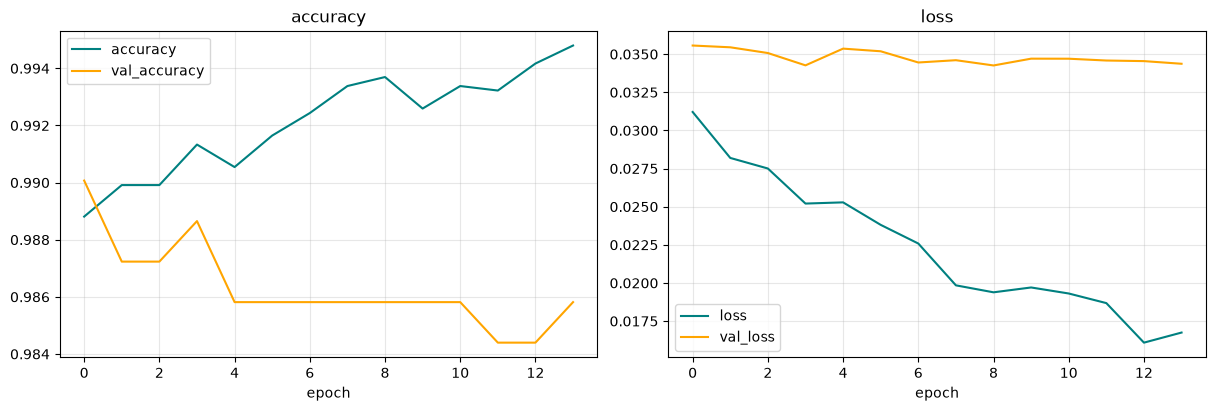

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
fig.get_layout_engine().set(w_pad=0.02, wspace=0.02)

axs[0].plot(history_finetune .history["accuracy"], color="teal", label="accuracy")
axs[0].plot(history_finetune .history["val_accuracy"], color="orange", label="val_accuracy")
axs[0].set_title("accuracy")

axs[1].plot(history_finetune .history["loss"], color="teal", label="loss")
axs[1].plot(history_finetune .history["val_loss"], color="orange", label="val_loss")
axs[1].set_title("loss")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
    ax.legend()

plt.show()

In [38]:
for batch in test_data.as_numpy_iterator():
  X, y = batch
  yhat = model.predict(X)
  precision.update_state(y, yhat)
  recall.update_state(y, yhat)
  accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━

In [39]:
print(f"precision: {precision.result()}")
print(f"recall: {recall.result()}")
print(f"accuracy: {accuracy.result()}")

precision: 0.9751983880996704
recall: 0.9829999804496765
accuracy: 0.9789999723434448


In [40]:
model.save(MODEL_PATH)

In [41]:
model.save_weights(
    WEIGHTS_PATH
)

In [42]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpdqb376kx/assets


INFO:tensorflow:Assets written to: /tmp/tmpdqb376kx/assets


Saved artifact at '/tmp/tmpdqb376kx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_311')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132238298929232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298934800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298935760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298935376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298935568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132248820179280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298936336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298934992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298935952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298936720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322382989

W0000 00:00:1789583293.130039   77914 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789583293.130072   77914 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [43]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

tflite_optimized = converter.convert()

with open(
    OPTIMIZED_TFLITE_PATH,
    "wb"
) as f:
    f.write(tflite_optimized)

INFO:tensorflow:Assets written to: /tmp/tmpsiuk8vxs/assets


INFO:tensorflow:Assets written to: /tmp/tmpsiuk8vxs/assets


Saved artifact at '/tmp/tmpsiuk8vxs'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_311')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  132238298929232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298934800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298935760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298935376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298935568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132248820179280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298936336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298934992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298935952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132238298936720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1322382989

W0000 00:00:1789583297.221670   77914 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789583297.221701   77914 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


In [44]:
import os

print(
    "Normal:",
    os.path.getsize(TFLITE_PATH) / 1024 / 1024,
    "MB"
)

print(
    "Optimizado:",
    os.path.getsize(OPTIMIZED_TFLITE_PATH) / 1024 / 1024,
    "MB"
)

Normal: 3.5802764892578125 MB
Optimizado: 1.078948974609375 MB


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


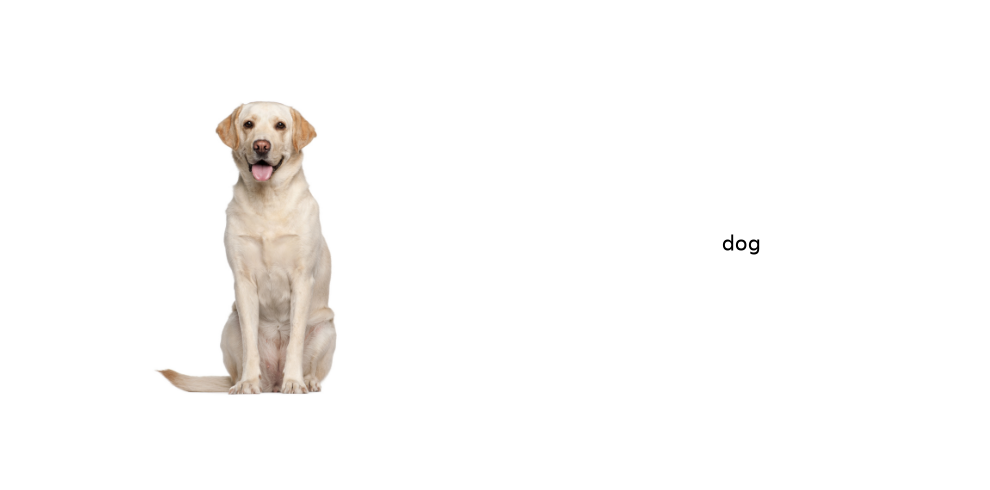

[[0.99983966]]


In [45]:
import keras
model = keras.saving.load_model(MODEL_PATH)

image = cv2.imread("dog.png")
if image is None:
    raise FileNotFoundError("Could not read dog.png from the current working directory.")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

img = np.expand_dims(tf.image.resize(image, IMAGE_SIZE), 0)

y_hat = model.predict(img)

label = "dog" if y_hat > 0.5 else "cat"

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image)
axs[0].axis('off')
axs[1].text(0.5, 0.5, label, fontsize=15, ha='center', va='center')
axs[1].axis('off')
plt.tight_layout()
plt.show()

print(y_hat)